This file analyzes the "preference alignment" dataset and focuses on verifying whether the assumptions in 5.2 are empirically solid.
The code will compute the averaged mutual information between a human and another human or a type of AI conditioned on another type of AI.

In [22]:
"""
Load the dataset, then store it
"""

import pandas as pd
import numpy as np
df = pd.read_json("hf://datasets/allenai/multipref/MultiPref-Train.jsonl", lines=True)

normal_list = []
expert_list = []
for index, row in df.iterrows():
    worker_answer = row["normal_worker_annotations"]
    expert_answer = row["expert_worker_annotations"]
    for i in range(len(worker_answer)):
        worker_id = worker_answer[i]['evaluator']
        if worker_id not in normal_list:
            normal_list.append(worker_id)
    for i in range(len(expert_answer)):
        expert_id = expert_answer[i]['evaluator']
        if expert_id not in expert_list:
            expert_list.append(expert_id)

worker_list = normal_list + expert_list
signals = {'A-is-clearly-better': 0, 'A-is-slightly-better': 1, 'Tie': 2, 'B-is-slightly-better':3, 'B-is-clearly-better': 4}
human_data = np.full((len(worker_list), len(df)), np.nan)
for j, row in df.iterrows():
    worker_answer = row["normal_worker_annotations"]
    expert_answer = row["expert_worker_annotations"]
    for i in range(len(worker_answer)):
        worker_id = worker_answer[i]['evaluator']
        index = worker_list.index(worker_id)
        r = signals[worker_answer[i]['overall_pref']]
        human_data[index, j] = r
    for i in range(len(expert_answer)):
        expert_id = expert_answer[i]['evaluator']
        index = worker_list.index(expert_id)
        r = signals[expert_answer[i]['overall_pref']]
        human_data[index, j] = r

answered_question = []
for i in range(np.size(human_data, axis = 0)):
    valid_index = np.where(~np.isnan(human_data[i,:]))[0]
    answered_question.append(len(valid_index))

print("The average number of questions that a labeler answers: ", np.average(answered_question))

The average number of questions that a labeler answers:  184.33480176211455


In [24]:
"""
Load AI labels
"""

import torch
import warnings
warnings.filterwarnings("ignore")

file_path = 'multipref/gpt-4o-mini/total_output_labels.pt'
signals = {'A-is-clearly-better': 0, 'A-is-better': 0, 'A-is-slightly-better': 1, 'Tie': 2, 'B-is-slightly-better':3, 'B-is-clearly-better': 4, 'B-is-better': 4}

llm_data = np.array(torch.load(file_path))
n = len(llm_data)

gpt4_data = np.ones(n)*np.nan
for i in range(len(llm_data)):
    if llm_data[i] ==  None:
        continue
    r = signals[llm_data[i]['final verdict']]
    gpt4_data[i] = r

file_path = 'multipref/gpt-4o-mini_1/total_output_labels.pt'
signals = {'A-is-clearly-better': 0, 'A-is-better': 0, 'A-is-slightly-better': 1, 'Tie': 2, 'B-is-slightly-better':3, 'B-is-clearly-better': 4, 'B-is-better': 4}

llm_data = np.array(torch.load(file_path))
n = len(llm_data)

gpt4_data_2 = np.ones(n)*np.nan
for i in range(len(llm_data)):
    if llm_data[i] ==  None:
        continue
    r = signals[llm_data[i]['final verdict']]
    gpt4_data_2[i] = r

file_path = 'multipref/gpt-4o-mini_2/total_output_labels.pt'
signals = {'A-is-clearly-better': 0, 'A-is-better': 0, 'A-is-slightly-better': 1, 'Tie': 2, 'B-is-slightly-better':3, 'B-is-clearly-better': 4, 'B-is-better': 4}

llm_data = np.array(torch.load(file_path))
n = len(llm_data)

gpt4_data_3 = np.ones(n)*np.nan
for i in range(len(llm_data)):
    if llm_data[i] ==  None:
        continue
    r = signals[llm_data[i]['final verdict']]
    gpt4_data_3[i] = r
    

file_path = 'multipref/gpt-3.5-turbo/total_output_labels.pt'
signals = {'A-is-clearly-better': 0, 'A-is-slightly-better': 1, 'Tie': 2, 'B-is-slightly-better':3, 'B-is-clearly-better': 4}

llm_data = np.array(torch.load(file_path))

gpt3_data = np.ones(n)*np.nan
for i in range(len(llm_data)):
    if llm_data[i] ==  None:
        continue
    if 'final verdict' in llm_data[i].keys():
        r = signals[llm_data[i]['final verdict']]
    else:
        r = signals[llm_data[i]['final_verdict']]
    gpt3_data[i] = r


file_path = 'multipref/gpt-3.5-turbo_1/total_output_labels.pt'
signals = {'A-is-clearly-better': 0, 'Response A-is-clearly-better': 0, 'A-is-slightly-better': 1, 'Tie': 2, 'B-is-slightly-better':3, 'B-is-clearly-better': 4}

llm_data = np.array(torch.load(file_path))

gpt3_data_2 = np.ones(n)*np.nan
for i in range(len(llm_data)):
    if llm_data[i] ==  None:
        continue
    if 'final verdict' in llm_data[i].keys():
        r = signals[llm_data[i]['final verdict']]
    else:
        r = signals[llm_data[i]['final_verdict']]
    gpt3_data_2[i] = r


file_path = 'multipref/gpt-3.5-turbo_2/total_output_labels.pt'
signals = {'A-is-clearly-better': 0, 'Response A is clearly better': 0, 'A-is-slightly-better': 1, 'Tie': 2, 'B-is-slightly-better':3, 'B-is-clearly-better': 4}

llm_data = np.array(torch.load(file_path))

gpt3_data_3 = np.ones(n)*np.nan
for i in range(len(llm_data)):
    if llm_data[i] ==  None:
        continue
    if 'final verdict' in llm_data[i].keys():
        r = signals[llm_data[i]['final verdict']]
    else:
        r = signals[llm_data[i]['final_verdict']]
    gpt3_data_3[i] = r
    

file_path = 'multipref/gemma-2-2b-it/output_labels_all.pt'
signals = {'A-is-clearly-better': 0, 'A-is-slightly-better': 1, 'o A-is-slightly-better': 1, 'Tie': 2, 'B-is-slightly-better':3, 'B-is-clearly-better': 4}

llm_data = np.array(torch.load(file_path))

gemma_data = np.ones(n)*np.nan
for i in range(len(llm_data)):
    if llm_data[i] ==  None:
        continue
    if 'final verdict' in llm_data[i].keys():
        if llm_data[i]['final verdict'] not in signals.keys():
            continue
        r = signals[llm_data[i]['final verdict']]
    elif 'final_verdict' in llm_data[i].keys():
        r = signals[llm_data[i]['final_verdict']]
    else:
        r = np.nan
    gemma_data[i] = r


file_path = 'multipref/gemma-2-2b-it_1/output_labels_all.pt'
signals = {'A-is-clearly-better': 0, 'A-is-slightly-better': 1, 'o A-is-slightly-better': 1, 'Tie': 2, 'B-is-slightly-better':3, 'B-is-clearly-better': 4}

llm_data = np.array(torch.load(file_path))

gemma_data_2 = np.ones(n)*np.nan
for i in range(len(llm_data)):
    if llm_data[i] ==  None:
        continue
    if 'final verdict' in llm_data[i].keys():
        if llm_data[i]['final verdict'] not in signals.keys():
            continue
        r = signals[llm_data[i]['final verdict']]
    elif 'final_verdict' in llm_data[i].keys():
        r = signals[llm_data[i]['final_verdict']]
    else:
        r = np.nan
    gemma_data_2[i] = r


file_path = 'multipref/gemma-2-2b-it_2/output_labels_all.pt'
signals = {'A-is-clearly-better': 0, 'A-is-slightly-better': 1, 'o A-is-slightly-better': 1, 'Tie': 2, 'B-is-slightly-better':3, 'B-is-clearly-better': 4}

llm_data = np.array(torch.load(file_path))

gemma_data_3 = np.ones(n)*np.nan
for i in range(len(llm_data)):
    if llm_data[i] ==  None:
        continue
    if 'final verdict' in llm_data[i].keys():
        if llm_data[i]['final verdict'] not in signals.keys():
            continue
        r = signals[llm_data[i]['final verdict']]
    elif 'final_verdict' in llm_data[i].keys():
        r = signals[llm_data[i]['final_verdict']]
    else:
        r = np.nan
    gemma_data_3[i] = r


file_path = 'multipref/Mistral-7B-Instruct-v0.3/output_labels_all.pt'
signals = {'A-is-clearly-better': 0, 'Response A-is-clearly-better': 0, 'A-is-slightly-better': 1, 'Response A-is-slightly-better': 1, 'Tie': 2, 'B-is-slightly-better':3, 'B-is-clearly-better': 4}

llm_data = np.array(torch.load(file_path))
n = len(llm_data)

mistral_data = np.ones(n)*np.nan
for i in range(len(llm_data)):
    if llm_data[i] ==  None:
        continue
    if 'final verdict' in llm_data[i].keys():
        if llm_data[i]['final verdict'] not in signals.keys():
            continue
        r = signals[llm_data[i]['final verdict']]
    elif 'final_verdict' in llm_data[i].keys():
        r = signals[llm_data[i]['final_verdict']]
    else:
        r = np.nan
    mistral_data[i] = r

file_path = 'multipref/Mistral-7B-Instruct-v0.3_1/output_labels_all.pt'
signals = {'A-is-clearly-better': 0, 'Response A-is-clearly-better': 0, 'A-is-slightly-better': 1, 'Response A-is-slightly-better': 1, 'Tie': 2, 'B-is-slightly-better':3, 'B-is-clearly-better': 4}

llm_data = np.array(torch.load(file_path))
n = len(llm_data)

mistral_data_2 = np.ones(n)*np.nan
for i in range(len(llm_data)):
    if llm_data[i] ==  None:
        continue
    if 'final verdict' in llm_data[i].keys():
        if llm_data[i]['final verdict'] not in signals.keys():
            continue
        r = signals[llm_data[i]['final verdict']]
    elif 'final_verdict' in llm_data[i].keys():
        r = signals[llm_data[i]['final_verdict']]
    else:
        r = np.nan
    mistral_data_2[i] = r

file_path = 'multipref/Mistral-7B-Instruct-v0.3_2/output_labels_all.pt'
signals = {'A-is-clearly-better': 0, 'Response A-is-clearly-better': 0, 'A-is-slightly-better': 1, 'Response A-is-slightly-better': 1, 'Tie': 2, 'B-is-slightly-better':3, 'B-is-clearly-better': 4}

llm_data = np.array(torch.load(file_path))
n = len(llm_data)

mistral_data_3 = np.ones(n)*np.nan
for i in range(len(llm_data)):
    if llm_data[i] ==  None:
        continue
    if 'final verdict' in llm_data[i].keys():
        if llm_data[i]['final verdict'] not in signals.keys():
            continue
        r = signals[llm_data[i]['final verdict']]
    elif 'final_verdict' in llm_data[i].keys():
        r = signals[llm_data[i]['final_verdict']]
    else:
        r = np.nan
    mistral_data_3[i] = r


file_path = 'multipref/Phi-3.5-mini-instruct/output_labels_all.pt'
signals = {'A-is-clearly-better': 0, 'A-is-slightly-better': 1, 'Tie': 2, 'tie': 2, 'B-is-slightly-better':3, 'B-is-clearly-better': 4}

llm_data = np.array(torch.load(file_path))
n = len(llm_data)

phi_data = np.ones(n)*np.nan
for i in range(len(llm_data)):
    if llm_data[i] ==  None:
        continue
    if 'final verdict' in llm_data[i].keys():
        if llm_data[i]['final verdict'] not in signals.keys():
            continue
        r = signals[llm_data[i]['final verdict']]
    elif 'final_verdict' in llm_data[i].keys():
        r = signals[llm_data[i]['final_verdict']]
    else:
        r = np.nan
    phi_data[i] = r

file_path = 'multipref/Phi-3.5-mini-instruct_1/output_labels_all.pt'
signals = {'A-is-clearly-better': 0, 'A-is-slightly-better': 1, 'Tie': 2, 'tie': 2, 'B-is-slightly-better':3, 'B-is-clearly-better': 4}

llm_data = np.array(torch.load(file_path))
n = len(llm_data)

phi_data_2 = np.ones(n)*np.nan
for i in range(len(llm_data)):
    if llm_data[i] ==  None:
        continue
    if 'final verdict' in llm_data[i].keys():
        if llm_data[i]['final verdict'] not in signals.keys():
            continue
        r = signals[llm_data[i]['final verdict']]
    elif 'final_verdict' in llm_data[i].keys():
        r = signals[llm_data[i]['final_verdict']]
    else:
        r = np.nan
    phi_data_2[i] = r

file_path = 'multipref/Phi-3.5-mini-instruct_2/output_labels_all.pt'
signals = {'A-is-clearly-better': 0, 'A-is-slightly-better': 1, 'Tie': 2, 'tie': 2, 'B-is-slightly-better':3, 'B-is-clearly-better': 4}

llm_data = np.array(torch.load(file_path))
n = len(llm_data)

phi_data_3 = np.ones(n)*np.nan
for i in range(len(llm_data)):
    if llm_data[i] ==  None:
        continue
    if 'final verdict' in llm_data[i].keys():
        if llm_data[i]['final verdict'] not in signals.keys():
            continue
        r = signals[llm_data[i]['final verdict']]
    elif 'final_verdict' in llm_data[i].keys():
        r = signals[llm_data[i]['final_verdict']]
    else:
        r = np.nan
    phi_data_3[i] = r

In [7]:
"""
Compute joint distributions
"""

import numpy as np
from collections import Counter
from collections import defaultdict

def empirical_joint(v1, v2, K):
    """
    Given two agents' report vectors v1 and v2 (iid samples of the report variables X1 and X2), and the size of the signal space K,
    compute the empirical point-wise joint distribution between X1 and X2.
    """
    v1 = np.array(v1)
    v2 = np.array(v2)
    
    mask = ~np.isnan(v1) & ~np.isnan(v2)
    
    valid_pairs = list(zip(v1[mask], v2[mask]))
    
    pair_counts = Counter(valid_pairs)
    
    joint_matrix = np.zeros((K, K))
    
    value_to_index = {val: idx for idx, val in enumerate(list(np.arange(K)))}
    
    total_pairs = len(valid_pairs)
    for (a, b), count in pair_counts.items():
        i, j = value_to_index[a], value_to_index[b]
        joint_matrix[i, j] = count / total_pairs
    
    return joint_matrix

def empirical_joint_conditioned(v1, v2, v3, K):
    """
    Given two agents' report vectors v1 and v2, the conditional report vector v3, and the size of the signal space K,
    compute the point-wise empirical joint distribution between X1 and X2 conditioned on X3
    """
    # Ensure inputs are numpy arrays
    v1 = np.array(v1)
    v2 = np.array(v2)
    v3 = np.array(v3)
    
    # Map each value in sigma to an index
    value_to_index = {val: idx for idx, val in enumerate(list(np.arange(K)))}
    
    # Initialize conditioned joint distribution tensor
    joint_tensor = np.zeros((K, K, K))
    
    # Create a defaultdict to count occurrences conditioned on v3
    conditioned_counts = defaultdict(Counter)
    
    # Mask to filter out nan entries in all vectors
    mask = ~np.isnan(v1) & ~np.isnan(v2) & ~np.isnan(v3)
    
    # Extract valid triples
    valid_triples = list(zip(v1[mask], v2[mask], v3[mask]))
    
    # Count occurrences of each pair (v1, v2) conditioned on v3
    for a, b, c in valid_triples:
        i, j, k = value_to_index[a], value_to_index[b], value_to_index[c]
        joint_tensor[k,i,j] += 1
    joint_tensor = joint_tensor / len(valid_triples)
    return joint_tensor

In [30]:
"""
Compute the (conditioned) mutual information given the empirical joint distribution.
Note that the KL (or TVD) mutual information is the KL (or TVD) divergence between the joint distribution and the product of marginal distributions.
"""

def Divergence(joint_matrix):
    P_X1 = np.sum(joint_matrix, axis=1)  # Sum over rows to get P(X1)
    P_X2 = np.sum(joint_matrix, axis=0)  # Sum over columns to get P(X2)
    product_matrix = np.outer(P_X1, P_X2)
    
    mask = (joint_matrix > 0) & (product_matrix > 0)
    
    # Compute KL divergence: sum(P(X1, X2) * log(P(X1, X2) / (P(X1) * P(X2))))
    kl_divergence = np.sum(joint_matrix[mask] * np.log(joint_matrix[mask] / product_matrix[mask]))
    tvd_divergence = np.sum(np.abs(joint_matrix - product_matrix))
    supremum_norm = np.max(np.abs(joint_matrix - product_matrix))
    
    return kl_divergence, tvd_divergence, supremum_norm


def Divergence_conditioned(joint_tensor):
    kl_divergences = 0
    tvd_divergence = 0
    supremum_norm = 0
    
    for k in range(K):
        joint_matrix = joint_tensor[k]
        
        if np.sum(joint_matrix) > 0:
            joint_matrix_norm = joint_matrix/np.sum(joint_matrix)
            kl, tvd, sup = Divergence(joint_matrix_norm)
        else:
            kl, tvd, sup = 0,0,0

        kl_divergences += np.sum(joint_matrix)*kl
        tvd_divergence += np.sum(joint_matrix)*tvd
        supremum_norm = np.max((supremum_norm, sup))

    return kl_divergences, tvd_divergence, supremum_norm

In [32]:
K = 5
n = np.size(human_data, axis=1) # number of questions
human_data_non_nan = np.full((4, n), np.nan)
for j in range(n):
    non_nan = np.where(~np.isnan(human_data[:,j]))[0]
    for i in range(4):
        human_data_non_nan[i,j] = human_data[non_nan[i],j]

human_reference = human_data_non_nan[3] # select the third human labeler (expert) as X_j
prior =  np.bincount(human_reference.astype(int).tolist(), minlength=K) / len(human_reference)
random_data = np.random.choice(len(prior), size=len(human_reference), p=prior) # simulate random responses as a baseline

conditioned_list = [gpt3_data_3, gpt4_data_3, gemma_data_3, mistral_data_3, phi_data_3] # iterate the AI that we condition on
response_list = [random_data, human_data_non_nan[0], human_data_non_nan[2], gpt3_data, gpt4_data, gemma_data, mistral_data, phi_data] # [0] is normal labeler and [2] is expert
names = ['Random Cheater', 'Normal worker', 'Expert', 'GPT-3.5', 'GPT-4', 'Gemma', 'Mistral', 'Phi']

kl_divergence = np.zeros((len(names)-2, len(names)))
tvd_divergence = np.zeros((len(names)-2, len(names)))
for j, response in enumerate(response_list):
    joint = empirical_joint(response, human_reference, K)
    kl_divergence[0,j], tvd_divergence[0,j], _ = Divergence(joint)
    
for i, conditioned_r in enumerate(conditioned_list):
    for j, response in enumerate(response_list):
        joint_cond = empirical_joint_conditioned(response, human_reference, conditioned_r, K)
        kl, tvd, _ = Divergence_conditioned(joint_cond)
        kl_divergence[i+1, j] = kl
        tvd_divergence[i+1, j] = tvd


In [34]:
import numpy as np
import matplotlib.pyplot as plt

def plot_grouped_bar_chart(matrix, group_names, bar_names, fig_name):
    """
    Plots a grouped bar chart for the given n*m matrix with custom colors.
    
    Parameters:
    matrix (numpy.ndarray): A 2D NumPy array of shape (n, m) where n is the number of groups
                            and m is the number of bars in each group.
    group_names (list): A list of length n containing the names of the groups.
    bar_names (list): A list of length m containing the names of the bars.
    """
    n, m = matrix.shape
    x = np.arange(n)  # Group positions
    width = 0.8 / m   # Width of each bar, evenly spaced within each group
    
    # Custom colors for the bars
    colors = ['#d62728', '#ff7f0e', '#d472cf', '#e69f00', '#2ca02c', '#9cd2db', '#1f77b4', '#7600c4']
    
    fig, ax = plt.subplots(figsize=(10, 6))

    # Plot each set of bars for each group with custom colors
    for i in range(m):
        ax.bar(x + i * width, matrix[:, i], width, label=bar_names[i], color=colors[i])
    
    # Add labels and title
    ax.set_xlabel(r'Conditioned LLM $Z$', fontsize = 18)
    ax.set_ylabel(r'$I_{\text{TVD}}(Z_i; X_j\mid Z)$', fontsize = 18)
    ax.set_xticks(x + width * (m - 1) / 2)
    ax.set_xticklabels(group_names, fontsize = 17)
    ax.grid(True, linestyle='--', linewidth=0.5, alpha=0.7)
    ax.tick_params(axis='y', labelsize=15)
    ax.legend(fontsize = 14)
    
    plt.tight_layout()
    # plt.show()
    plt.savefig(fig_name, dpi=300, bbox_inches='tight')

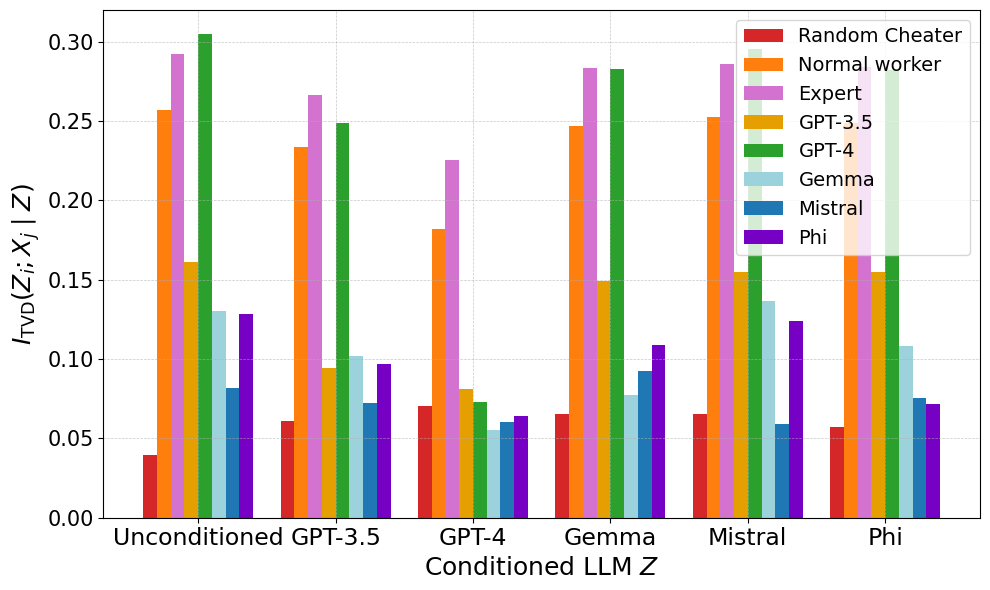

In [170]:
group_names = ['Unconditioned', 'GPT-3.5', 'GPT-4', 'Gemma', 'Mistral', 'Phi']
bar_names = names
fig_name = 'figures/tvd_divergence_Y_preference.png'
plot_grouped_bar_chart(tvd_divergence, group_names, bar_names, fig_name)

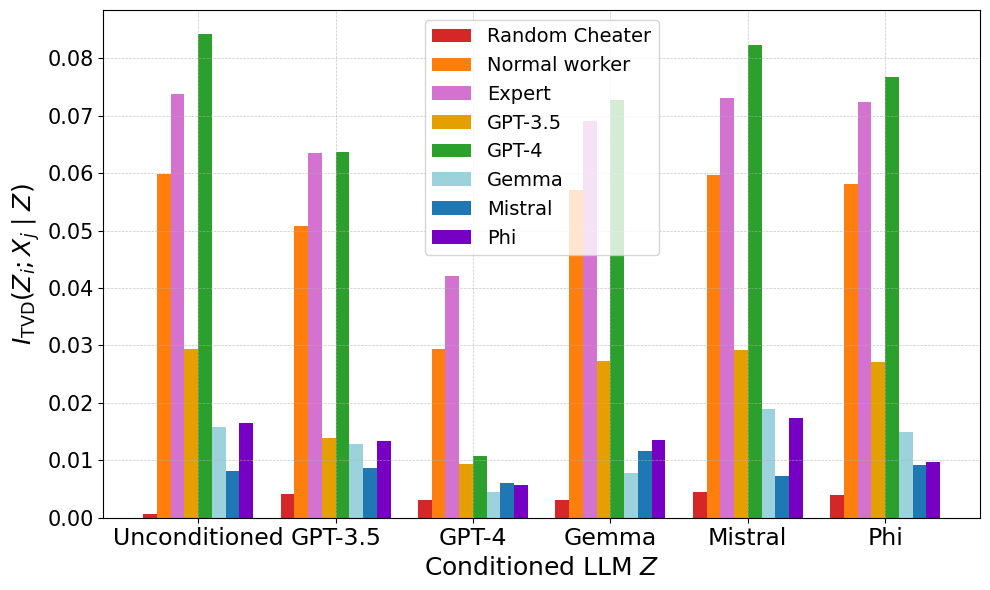

In [36]:
"""
Plot the conditioned mutual information between a human and another human or an AI
"""

group_names = ['Unconditioned', 'GPT-3.5', 'GPT-4', 'Gemma', 'Mistral', 'Phi']
bar_names = names
fig_name = 'figures/kl_divergence_Y_preference.png'
plot_grouped_bar_chart(kl_divergence, group_names, bar_names, fig_name)

In [44]:
"""
Compute the mutual information between a pair of AI agents.
This tests the case where two labelers both use AI to submit on their behalf.
"""

K = 5
n = np.size(human_data, axis=1)
human_data_non_nan = np.full((4, n), np.nan)
for j in range(n):
    non_nan = np.where(~np.isnan(human_data[:,j]))[0]
    for i in range(4):
        human_data_non_nan[i,j] = human_data[non_nan[i],j]

conditioned_list = [gpt3_data_3, gpt4_data_3, gemma_data_3, mistral_data_3, phi_data_3]
response_list_1 = [gpt3_data, gpt4_data, gemma_data, mistral_data, phi_data]
response_list_2 = [gpt3_data_2, gpt4_data_2, gemma_data_2, mistral_data_2, phi_data_2]
names = ['GPT-3.5', 'GPT-4', 'Gemma', 'Mistral', 'Phi']

tvd_cond_zz = np.zeros((len(response_list_1), len(response_list_2)))
for i, response_1 in enumerate(response_list_1):
    conditioned_r = conditioned_list[i]
    for j, response_2 in enumerate(response_list_2):
        joint_cond = empirical_joint_conditioned(response_1, response_2, conditioned_r, K)
        kl, tvd, _ = Divergence_conditioned(joint_cond)
        tvd_cond_zz[i, j] = tvd

tvd_cond_human = np.zeros(len(conditioned_list))
for i, conditioned_r in enumerate(conditioned_list):
    joint_cond = empirical_joint_conditioned(human_data_non_nan[2], human_data_non_nan[3], conditioned_r, K)
    kl, tvd, _ = Divergence_conditioned(joint_cond)
    tvd_cond_human[i] = tvd

def print_array(array, names, precision=4, padding=2):
    """
    Prints a square numpy array with aligned row and column names.
    """

    # determine column width
    num_width = precision + 6   # sign + digit + dot + decimals
    name_width = max(len(n) for n in names)
    col_width = max(num_width, name_width) + padding

    # header
    print(" " * col_width, end="")
    for name in names:
        print(f"{name:>{col_width}}", end="")
    print()

    # rows
    for name, row in zip(names, array):
        print(f"{name:>{col_width}}", end="")
        for val in row:
            print(f"{val:>{col_width}.{precision}f}", end="")
        print()

print_array(tvd_cond_human[:, np.newaxis] - tvd_cond_zz, names)

                 GPT-3.5       GPT-4       Gemma     Mistral         Phi
     GPT-3.5      0.0412      0.0694      0.1802      0.1443      0.1355
       GPT-4      0.1537     -0.0307      0.1682      0.1701      0.1530
       Gemma      0.1819      0.1066      0.0379      0.2177      0.1659
     Mistral      0.1938      0.1726      0.2238      0.0508      0.1894
         Phi      0.1969      0.1542      0.1988      0.1914      0.0364
